# Doom vs Animal Crossing — CNN Classifier (PyTorch)

- **평가 지표**: Balanced Accuracy  
- **규칙**: Pre-trained model 사용 금지 — 처음부터 CNN 직접 구축  
- **참조 노트북 기법 적용**: CustomDataset (PIL 직접 로드, CSV 기반), AdamW, F1 추적, ImageNet 정규화, 224×224

In [1]:
import sys
!{sys.executable} -m pip install -q torch torchvision torchaudio torchmetrics pandas numpy scikit-learn matplotlib seaborn tqdm


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchmetrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: mps
PyTorch: 2.12.0


## 1. 경로 및 하이퍼파라미터 설정

In [3]:
# ─────────────────────────────────────────────────────────────
#  여기만 수정: train-label.csv, test-label.csv, img/ 폴더가
#  있는 디렉토리의 경로를 입력하세요
# ─────────────────────────────────────────────────────────────
BASE_DIR = Path('.').resolve()   # 예: Path('/Users/yourname/Downloads/knu_ml')
IMG_DIR  = BASE_DIR / 'img'

WORK_DIR   = BASE_DIR / 'working'
MODEL_PATH = WORK_DIR / 'best_model.pth'
WORK_DIR.mkdir(parents=True, exist_ok=True)

# 하이퍼파라미터 — 참조 노트북과 동일한 224×224, ImageNet 정규화
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 60
VAL_SPLIT  = 0.15
LR         = 1e-3
PATIENCE   = 12      # early stopping patience
NUM_WORKERS = 0      # macOS에서 안전하게 0; Kaggle/Linux면 4로 올려도 됨

# ImageNet 정규화 (참조 노트북과 동일)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

print(f'BASE_DIR: {BASE_DIR}')
print(f'IMG_DIR : {IMG_DIR}  exists={IMG_DIR.exists()}')

BASE_DIR: /Users/dayana/git repo/machine-learning-class/lab5
IMG_DIR : /Users/dayana/git repo/machine-learning-class/lab5/img  exists=True


## 2. 데이터 로드

In [4]:
TRAIN_LABEL  = pd.read_csv(BASE_DIR / 'train-label.csv', index_col='id')
TEST_LABEL   = pd.read_csv(BASE_DIR / 'test-label.csv',  index_col='id')
SUB_TEMPLATE = pd.read_csv(BASE_DIR / 'submission.csv')

print(f'Train: {len(TRAIN_LABEL)}, Test: {len(TEST_LABEL)}')
print('Label distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())

# img/ 폴더 탐색 → 파일명:절대경로 매핑 (참조 노트북의 glob 방식 개선)
img_files = (list(IMG_DIR.rglob('*.jpg'))
           + list(IMG_DIR.rglob('*.jpeg'))
           + list(IMG_DIR.rglob('*.png')))
file_map = {f.name: str(f.resolve()) for f in img_files}

print(f'\n이미지 파일 발견: {len(img_files)}개')
# 매핑 검증
for fname in TRAIN_LABEL['file'].head(5):
    print(f"  {'✅' if fname in file_map else '❌ 없음'} {fname}")

Train: 1385, Test: 1386
Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64

이미지 파일 발견: 2771개
  ✅ 001bd5563b4511f0b16c00155d672fff.png
  ✅ d13cde743b4411f0b16c00155d672fff.jpg
  ✅ 96f4bf1a3b4511f0b16c00155d672fff.jpg
  ✅ 43f18faa3b4511f0b16c00155d672fff.jpg
  ✅ bf0df3a03b4411f0b16c00155d672fff.png


## 3. Dataset 클래스 정의 (참조 노트북의 CustomDataset 방식 적용)

폴더 복사 없이 CSV에서 직접 파일 경로를 매핑합니다.

In [5]:
class MemeDataset(Dataset):
    """Doom vs Animal Crossing 데이터셋.
    참조 노트북의 CustomDataset을 우리 CSV 구조에 맞게 재구현.
    폴더 복사 없이 PIL로 직접 이미지를 로드합니다.
    """

    def __init__(self, df, file_map, transform=None, is_test=False):
        """
        df       : train-label.csv 또는 test-label.csv (index=id)
        file_map : {파일명: 절대경로} 딕셔너리
        transform: torchvision transforms
        is_test  : True면 label 반환 안 함
        """
        self.transform = transform
        self.is_test   = is_test
        self.ids       = df.index.tolist()

        # 경로 및 레이블 준비
        self.paths  = [file_map.get(row['file'], None) for _, row in df.iterrows()]
        self.labels = None if is_test else df['label'].tolist()

        # 파일 누락 체크
        missing = sum(1 for p in self.paths if p is None)
        if missing:
            print(f'⚠️  {missing}개 이미지 경로 없음 — IMG_DIR 확인 필요')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]

        # 경로가 없으면 빈 이미지로 대체
        if path is None:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        else:
            img = Image.open(path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        if self.is_test:
            return img, self.ids[idx]   # (tensor, id)
        return img, self.labels[idx]    # (tensor, label)


# ── Transform 정의 ────────────────────────────────────────────
# 학습용: 참조 노트북보다 강한 증강 적용
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(15),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

# 검증/테스트용: 증강 없이 resize + normalize만
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])


# ── Train / Val stratified split ─────────────────────────────
train_df, val_df = train_test_split(
    TRAIN_LABEL,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=TRAIN_LABEL['label']
)
print(f'Train: {len(train_df)}, Val: {len(val_df)}')

train_ds = MemeDataset(train_df, file_map, transform=train_transform)
val_ds   = MemeDataset(val_df,   file_map, transform=val_transform)
test_ds  = MemeDataset(TEST_LABEL, file_map, transform=val_transform, is_test=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train batches: {len(train_dl)}, Val batches: {len(val_dl)}, Test batches: {len(test_dl)}')

Train: 1177, Val: 208
Train batches: 37, Val batches: 7, Test batches: 44


## 4. 모델 정의 — Residual CNN (처음부터 구축, Pre-trained 금지)

Depthwise Separable Convolution + Residual Connection 기반 커스텀 CNN.

In [6]:
class DepthwiseSeparableConv(nn.Module):
    """Depthwise Separable Convolution (MobileNet 방식)"""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1,
                            groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.pw(self.dw(x))), inplace=True)


class ResBlock(nn.Module):
    """Separable Conv 기반 Residual Block"""
    def __init__(self, channels, stride=1):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(channels, channels, stride=stride)
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.shortcut = nn.Sequential()
        if stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(channels, channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(channels),
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        return F.relu(out + self.shortcut(x), inplace=True)


class CustomCNN(nn.Module):
    """
    처음부터 구축한 Custom CNN.
    Pre-trained 가중치 일절 사용하지 않음.
    입력: (B, 3, 224, 224)
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),  # 112
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=1, padding=1, bias=False),  # 112
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )

        # Stage 1: 112 → 56
        self.stage1 = nn.Sequential(
            self._make_layer(64,  64,  n=2, first_stride=2),
        )
        # Stage 2: 56 → 28
        self.stage2 = nn.Sequential(
            self._make_layer(64,  128, n=3, first_stride=2),
        )
        # Stage 3: 28 → 14
        self.stage3 = nn.Sequential(
            self._make_layer(128, 256, n=4, first_stride=2),
        )
        # Stage 4: 14 → 7
        self.stage4 = nn.Sequential(
            self._make_layer(256, 512, n=2, first_stride=2),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def _make_layer(self, in_ch, out_ch, n, first_stride):
        """채널 변환 conv → n개 ResBlock"""
        layers = [
            nn.Conv2d(in_ch, out_ch, 1, stride=first_stride, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        for _ in range(n):
            layers.append(ResBlock(out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        return self.head(x)


model = CustomCNN(num_classes=2).to(DEVICE)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# 입력 shape 테스트
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape: {out.shape}  ✅')

Total parameters: 8,800,418
Output shape: torch.Size([2, 2])  ✅


## 5. TrainValidation 클래스 (참조 노트북 구조 그대로 적용)

In [7]:
class TrainValidation:
    """
    참조 노트북의 TrainValidation 클래스를 우리 프로젝트에 맞게 재구현.
    - AdamW optimizer + CosineAnnealingLR scheduler
    - F1Score 기준 best model 저장
    - Early stopping
    """

    def __init__(self, model, tr_dl, val_dl, device,
                 lr=LR, epochs=EPOCHS, patience=PATIENCE,
                 model_path=MODEL_PATH):
        self.model      = model
        self.tr_dl      = tr_dl
        self.val_dl     = val_dl
        self.device     = device
        self.epochs     = epochs
        self.patience   = patience
        self.model_path = model_path

        self.loss_fn   = nn.CrossEntropyLoss()
        # 참조 노트북과 동일: AdamW
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        # CosineAnnealing으로 lr 스케줄링 (참조 노트북 없던 부분, 추가 개선)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=epochs, eta_min=1e-6
        )
        # 참조 노트북과 동일: torchmetrics F1
        self.f1_metric = torchmetrics.F1Score(
            task='multiclass', num_classes=2, average='macro'
        ).to(device)

        self.best_f1       = 0.0
        self.not_improved  = 0

        self.tr_losses, self.val_losses = [], []
        self.tr_accs,   self.val_accs   = [], []
        self.tr_f1s,    self.val_f1s    = [], []

    # ── 한 epoch 학습 ────────────────────────────────────────
    def train_epoch(self):
        self.model.train()
        total_loss, correct = 0.0, 0
        self.f1_metric.reset()

        for ims, gts in tqdm(self.tr_dl, desc='Train', leave=False):
            ims, gts = ims.to(self.device), gts.to(self.device)
            preds    = self.model(ims)
            loss     = self.loss_fn(preds, gts)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * gts.size(0)
            correct    += (preds.argmax(1) == gts).sum().item()
            self.f1_metric.update(preds, gts)

        n   = len(self.tr_dl.dataset)
        return total_loss / n, correct / n, self.f1_metric.compute().item()

    # ── 한 epoch 검증 ────────────────────────────────────────
    def validate_epoch(self):
        self.model.eval()
        total_loss, correct = 0.0, 0
        self.f1_metric.reset()

        with torch.no_grad():
            for ims, gts in tqdm(self.val_dl, desc='Val  ', leave=False):
                ims, gts = ims.to(self.device), gts.to(self.device)
                preds    = self.model(ims)
                loss     = self.loss_fn(preds, gts)

                total_loss += loss.item() * gts.size(0)
                correct    += (preds.argmax(1) == gts).sum().item()
                self.f1_metric.update(preds, gts)

        n = len(self.val_dl.dataset)
        return total_loss / n, correct / n, self.f1_metric.compute().item()

    # ── 전체 학습 루프 ────────────────────────────────────────
    def fit(self):
        print(f'학습 시작 | Device: {self.device} | Epochs: {self.epochs}\n')

        for epoch in range(1, self.epochs + 1):
            tr_loss,  tr_acc,  tr_f1  = self.train_epoch()
            val_loss, val_acc, val_f1 = self.validate_epoch()
            self.scheduler.step()

            self.tr_losses.append(tr_loss);  self.val_losses.append(val_loss)
            self.tr_accs.append(tr_acc);     self.val_accs.append(val_acc)
            self.tr_f1s.append(tr_f1);       self.val_f1s.append(val_f1)

            lr_now = self.optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch:02d}/{self.epochs}]  '
                  f'Loss {tr_loss:.4f}/{val_loss:.4f}  '
                  f'Acc {tr_acc:.4f}/{val_acc:.4f}  '
                  f'F1 {tr_f1:.4f}/{val_f1:.4f}  '
                  f'lr={lr_now:.2e}')

            # 참조 노트북과 동일: F1 기준 best model 저장
            if val_f1 > self.best_f1 + 1e-4:
                self.best_f1 = val_f1
                torch.save(self.model.state_dict(), self.model_path)
                print(f'  ✅ Best model saved  (val_f1={val_f1:.4f})')
                self.not_improved = 0
            else:
                self.not_improved += 1
                if self.not_improved >= self.patience:
                    print(f'  ⏹  Early stopping (patience={self.patience})')
                    break

        print(f'\n학습 완료. Best val F1: {self.best_f1:.4f}')


trainer = TrainValidation(model, train_dl, val_dl, DEVICE)
trainer.fit()

학습 시작 | Device: mps | Epochs: 60



Epoch [01/60]  Loss 0.7037/1.1938  Acc 0.6058/0.6731  F1 0.6056/0.6716  lr=9.99e-04
  ✅ Best model saved  (val_f1=0.6716)


Epoch [02/60]  Loss 0.6649/0.7441  Acc 0.6474/0.5721  F1 0.6472/0.5319  lr=9.97e-04


Epoch [03/60]  Loss 0.6185/0.5879  Acc 0.6950/0.7212  F1 0.6944/0.7211  lr=9.94e-04
  ✅ Best model saved  (val_f1=0.7211)


Epoch [04/60]  Loss 0.5910/0.5712  Acc 0.6967/0.7452  F1 0.6945/0.7450  lr=9.89e-04
  ✅ Best model saved  (val_f1=0.7450)


...

Epoch [37/60]  Loss 0.4660/0.4424  Acc 0.7944/0.7981  F1 0.7942/0.7969  lr=3.21e-04


Epoch [38/60]  Loss 0.4292/0.4641  Acc 0.8003/0.7788  F1 0.7999/0.7788  lr=2.97e-04


Epoch [39/60]  Loss 0.4667/0.4765  Acc 0.7910/0.7644  F1 0.7906/0.7610  lr=2.74e-04


Epoch [40/60]  Loss 0.4425/0.4371  Acc 0.7850/0.8029  F1 0.7850/0.8028  lr=2.51e-04


Epoch [41/60]  Loss 0.4471/0.5015  Acc 0.7918/0.7644  F1 0.7916/0.7644  lr=2.28e-04
  ⏹  Early stopping (patience=12)

학습 완료. Best val F1: 0.8118


## 6. 학습 곡선 시각화 (참조 노트북의 PlotLearningCurves 방식)

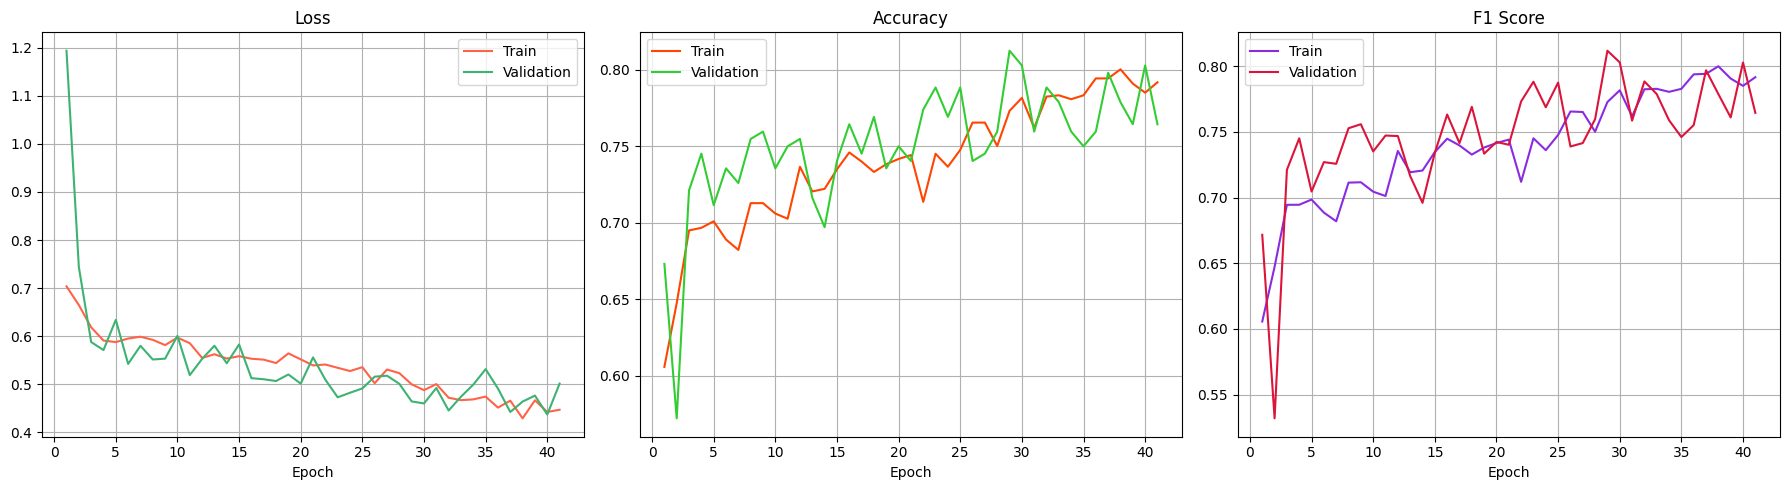

Best val F1: 0.8118


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(trainer.tr_losses) + 1)

axes[0].plot(epochs_range, trainer.tr_losses,  label='Train',      color='#FF6347')
axes[0].plot(epochs_range, trainer.val_losses, label='Validation', color='#3CB371')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, trainer.tr_accs,  label='Train',      color='#FF4500')
axes[1].plot(epochs_range, trainer.val_accs, label='Validation', color='#32CD32')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_range, trainer.tr_f1s,  label='Train',      color='#8A2BE2')
axes[2].plot(epochs_range, trainer.val_f1s, label='Validation', color='#DC143C')
axes[2].set_title('F1 Score'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig(str(WORK_DIR / 'training_curves.png'), dpi=100)
plt.show()
print(f'Best val F1: {trainer.best_f1:.4f}')

## 7. 검증 세트 Balanced Accuracy 평가

Validation Balanced Accuracy: 0.8116

                    precision    recall  f1-score   support

           Doom(0)       0.79      0.86      0.82       106
Animal Crossing(1)       0.84      0.76      0.80       102

          accuracy                           0.81       208
         macro avg       0.82      0.81      0.81       208
      weighted avg       0.81      0.81      0.81       208



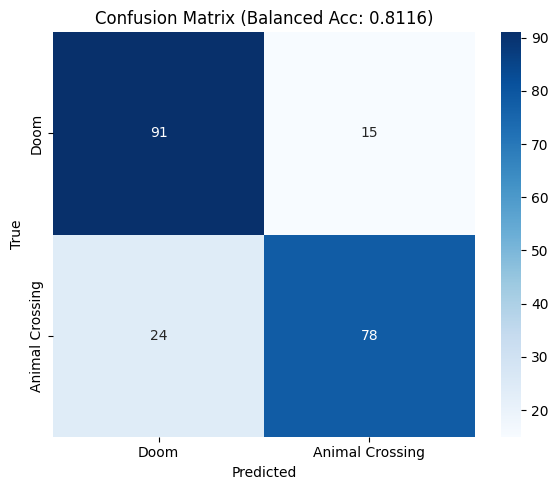

In [9]:
# Best model 로드
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for ims, gts in val_dl:
        ims = ims.to(DEVICE)
        logits = model(ims)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(gts.numpy())

ba = balanced_accuracy_score(all_labels, all_preds)
print(f'Validation Balanced Accuracy: {ba:.4f}')
print()
print(classification_report(all_labels, all_preds,
                             target_names=['Doom(0)', 'Animal Crossing(1)']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Doom', 'Animal Crossing'],
            yticklabels=['Doom', 'Animal Crossing'])
plt.title(f'Confusion Matrix (Balanced Acc: {ba:.4f})')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'confusion_matrix.png'), dpi=100)
plt.show()

## 8. 테스트 예측 + TTA (Test Time Augmentation)

In [10]:
# TTA: 원본 + 좌우 반전 + 2회 랜덤 증강 → 평균
tta_transforms = [
    val_transform,   # 원본
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(mean=MEAN, std=STD)]),  # 수평 반전
]

model.eval()
tta_probs = None
all_ids   = []

for tf_idx, tta_tf in enumerate(tta_transforms):
    tta_ds = MemeDataset(TEST_LABEL, file_map, transform=tta_tf, is_test=True)
    tta_dl = DataLoader(tta_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    probs_list, ids_list = [], []
    with torch.no_grad():
        for ims, ids in tqdm(tta_dl, desc=f'TTA {tf_idx+1}/{len(tta_transforms)}'):
            ims    = ims.to(DEVICE)
            logits = model(ims)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(probs)
            if tf_idx == 0:
                ids_list.extend(ids.numpy() if torch.is_tensor(ids) else ids)

    batch_probs = np.concatenate(probs_list, axis=0)
    if tta_probs is None:
        tta_probs = batch_probs
        all_ids   = ids_list
    else:
        tta_probs += batch_probs

tta_probs /= len(tta_transforms)
final_preds = tta_probs.argmax(axis=1)

print(f'예측 완료: {len(final_preds)}개')
print(f'Doom(0): {(final_preds==0).sum()}, Animal Crossing(1): {(final_preds==1).sum()}')

TTA 2/2: 100%|██████████| 44/44 [00:17<00:00,  2.55it/s]

예측 완료: 1386개
Doom(0): 742, Animal Crossing(1): 644


## 9. 제출 파일 생성 및 검증

In [11]:
# id → 예측 매핑
pred_map = dict(zip(all_ids, final_preds.tolist()))

sub_df = SUB_TEMPLATE.copy()
sub_df['label'] = sub_df['id'].map(pred_map)

missing = sub_df['label'].isna().sum()
if missing:
    print(f'⚠️  {missing}개 ID 매핑 실패 — 0으로 채움')
    sub_df['label'] = sub_df['label'].fillna(0)

sub_df['label'] = sub_df['label'].astype(int)

out_path = WORK_DIR / 'submission.csv'
sub_df.to_csv(out_path, index=False)

print(f'제출 파일 저장: {out_path}')
print(sub_df.head(10))
print('\nLabel 분포:')
print(sub_df['label'].value_counts())

# 유효성 검사
assert list(sub_df.columns) == ['id', 'label'], '컬럼 오류'
assert sub_df['label'].isin([0, 1]).all(),       '레이블 값 오류'
assert len(sub_df) == len(SUB_TEMPLATE),          '행 수 불일치'
print('\n✅ 유효성 검사 통과! submission.csv를 Kaggle에 제출하세요.')

제출 파일 저장: /Users/dayana/git repo/machine-learning-class/lab5/working/submission.csv
     id  label
0  2078      0
1  2079      1
2  2080      0
3  2081      0
4  2082      1
5  2083      1
6  2084      0
7  2085      0
8  2086      0
9  2087      0

Label 분포:
label
0    742
1    644
Name: count, dtype: int64

✅ 유효성 검사 통과! submission.csv를 Kaggle에 제출하세요.
